<a href="https://colab.research.google.com/github/aggelikntaliani-lgtm/scRNA-seq-Rstudio/blob/main/scRNAseq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install scanpy

In [5]:
import scanpy as sc

In [7]:
adata = sc.read_csv('GSM5226574_C51ctr_raw_counts.csv.gz').T
adata

AnnData object with n_obs × n_vars = 6099 × 34546

In [8]:
adata.X.shape

(6099, 34546)

In [9]:
!pip install scvi-tools

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 67.9 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=c803b48b7c63bbbb3077217b3bfe824771402aeabcabbc6f6a9f45a0eb0c8554
  Stor

In [10]:
import scvi

In [14]:
adata

AnnData object with n_obs × n_vars = 6099 × 2000
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'

In [12]:
sc.pp.filter_genes(adata, min_cells = 10)

In [13]:
sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = True, flavor = 'seurat_v3')

In [15]:
scvi.model.SCVI.setup_anndata(adata)
vae = scvi.model.SCVI(adata)
vae.train()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


In [18]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train()

INFO     Creating doublets, preparing SOLO model.                                                                  


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.284. Signaling Trainer to stop.


In [29]:
df = solo.predict()
df['prediction'] = solo.predict(soft = False)
df

/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)


,doublet,singlet,prediction
TAGGTACCATGGCCAC-1_1,0.876886,0.123114,doublet
ATTCACTGTAACAGGC-1_1,0.893032,0.106968,doublet
TAACTTCCAACCACGC-1_1,0.728774,0.271226,doublet
TTGGGTACACGACAAG-1_1,0.858639,0.141361,doublet
AGGCCACAGAGTCACG-1_1,0.690996,0.309004,doublet
...,...,...,...
CGCCATTGTTTGCCGG-1_1,0.086091,0.913909,singlet
CACTGGGGTCTACGTA-1_1,0.001155,0.998845,singlet
CATACTTGTAGAGGAA-1_1,0.002437,0.997563,singlet
TTTGGTTTCCACGGAC-1_1,0.000817,0.999183,singlet


In [24]:
df.groupby('prediction').count()

,doublet,singlet
prediction,,
doublet,1071,1071
singlet,5028,5028


In [32]:
df['dif'] = df.doublet - df.singlet
df

,doublet,singlet,prediction,dif
TAGGTACCATGGCCAC-1_1,0.876886,0.123114,doublet,0.753772
ATTCACTGTAACAGGC-1_1,0.893032,0.106968,doublet,0.786064
TAACTTCCAACCACGC-1_1,0.728774,0.271226,doublet,0.457549
TTGGGTACACGACAAG-1_1,0.858639,0.141361,doublet,0.717278
AGGCCACAGAGTCACG-1_1,0.690996,0.309004,doublet,0.381991
...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,0.086091,0.913909,singlet,-0.827819
CACTGGGGTCTACGTA-1_1,0.001155,0.998845,singlet,-0.997689
CATACTTGTAGAGGAA-1_1,0.002437,0.997563,singlet,-0.995125
TTTGGTTTCCACGGAC-1_1,0.000817,0.999183,singlet,-0.998366


In [26]:
import seaborn as sns

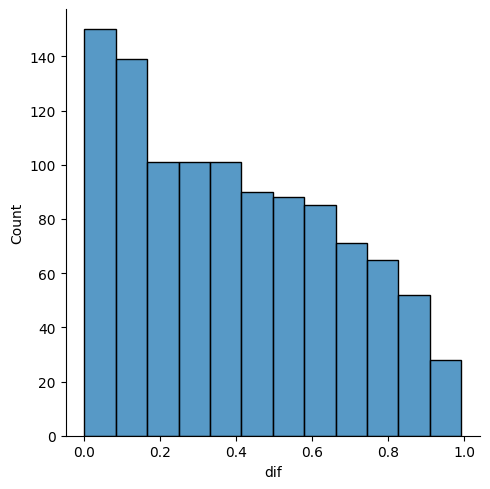

In [27]:
sns.displot(df[df.prediction == 'doublet'], x = 'dif')

In [37]:
doublets = df[(df.prediction == 'doublet') & (df.dif > 0.4)]
doublets

,doublet,singlet,prediction,dif
TAGGTACCATGGCCAC-1_1,0.876886,0.123114,doublet,0.753772
ATTCACTGTAACAGGC-1_1,0.893032,0.106968,doublet,0.786064
TAACTTCCAACCACGC-1_1,0.728774,0.271226,doublet,0.457549
TTGGGTACACGACAAG-1_1,0.858639,0.141361,doublet,0.717278
CACTGAAGTCGAAGCA-1_1,0.816429,0.183571,doublet,0.632857
...,...,...,...,...
ACAGAAATCTACCACC-1_1,0.784777,0.215223,doublet,0.569554
TCAGCAAAGCAACTTC-1_1,0.749933,0.250067,doublet,0.499866
GTCATTTTCTAACGGT-1_1,0.733672,0.266328,doublet,0.467343
ATCAGGTGTCGTCTCT-1_1,0.881189,0.118811,doublet,0.762378


In [41]:
adata = sc.read_csv('GSM5226574_C51ctr_raw_counts.csv.gz').T

In [43]:
adata.obs['doublet'] = adata.obs.index.isin(doublets.index)

In [44]:
adata.obs

,doublet
TAGGTACCATGGCCAC-1_1,True
ATTCACTGTAACAGGC-1_1,True
TAACTTCCAACCACGC-1_1,True
TTGGGTACACGACAAG-1_1,True
AGGCCACAGAGTCACG-1_1,False
...,...
CGCCATTGTTTGCCGG-1_1,False
CACTGGGGTCTACGTA-1_1,False
CATACTTGTAGAGGAA-1_1,False
TTTGGTTTCCACGGAC-1_1,False


In [45]:
adata = adata[~adata.obs.doublet]

In [46]:
adata

View of AnnData object with n_obs × n_vars = 5599 × 34546
    obs: 'doublet'

In [51]:
adata.var['mt'] = adata.var.index.str.startswith('MT-')

/tmp/ipykernel_470/310233584.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['mt'] = adata.var.index.str.startswith('MT-')


In [52]:
adata.var

,mt
AL627309.1,False
AL627309.5,False
AL627309.4,False
AL669831.2,False
LINC01409,False
...,...
VN1R2,False
AL031676.1,False
SMIM34A,False
AL050402.1,False
